In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import os
import numpy as np

def get_pftfiles_adsp(prefix, year_range = range(50,100)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h2.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

def get_colfiles_adsp(prefix, year_range = range(50,100)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h1.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files


def get_pftfiles_fnsp(prefix, year_range = range(10)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h1.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

def get_colfiles_fnsp(prefix, year_range = range(10)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h0.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files


def get_pftfiles_trmt(prefix, plot, year_range = range(10)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB20TRCNP{nutrient}CTCBC', 'spruce_treatments',
                            f'plot{plot}_US-SPR_ICB20TRCNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h2.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

In [30]:
flist = get_pftfiles_adsp('20240311_1', range(195,201))
hr2 = xr.open_mfdataset(flist)

KeyError: 'ZWT_ROOT_PATCH'

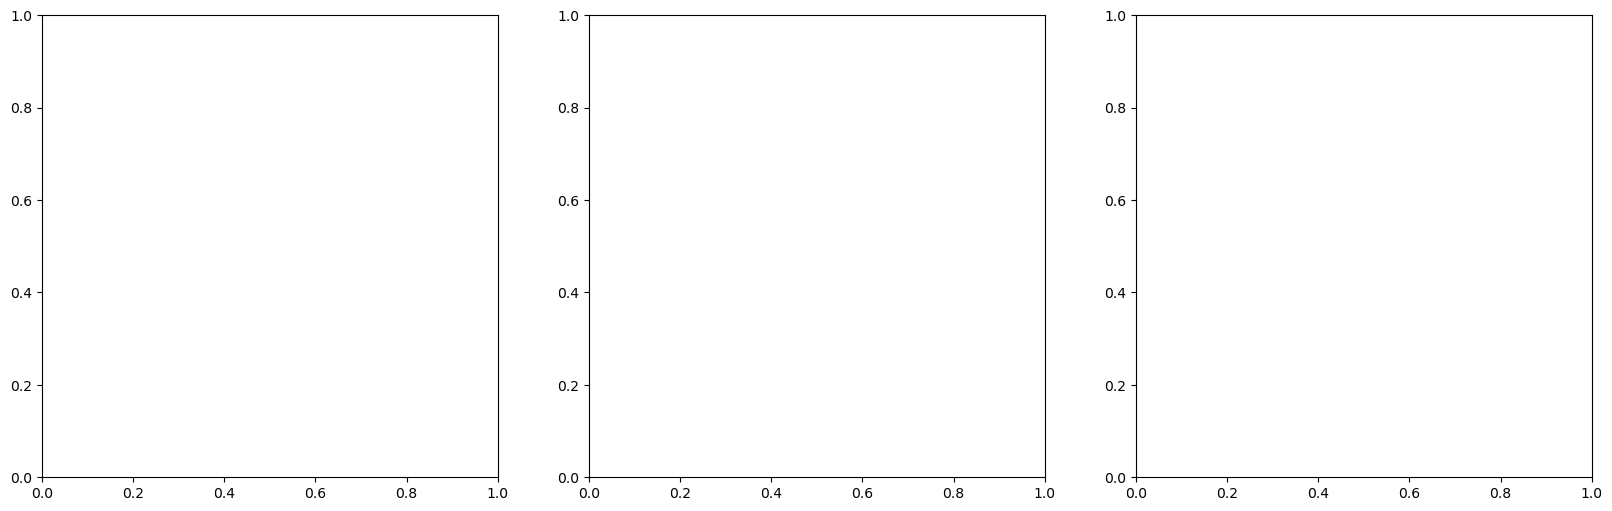

In [4]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    frac_fungi = hr2['ZWT_ROOT_PATCH'][:, pft].resample(time='1M').mean()
    frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft, ax = ax)

    frac_fungi = hr2['ZWT_ROOT_PATCH'][:, pft + 17].resample(time='1M').mean()
    frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft + 17, ax = ax)

    ax.legend()
    ax.set_ylabel('frac_fungi')

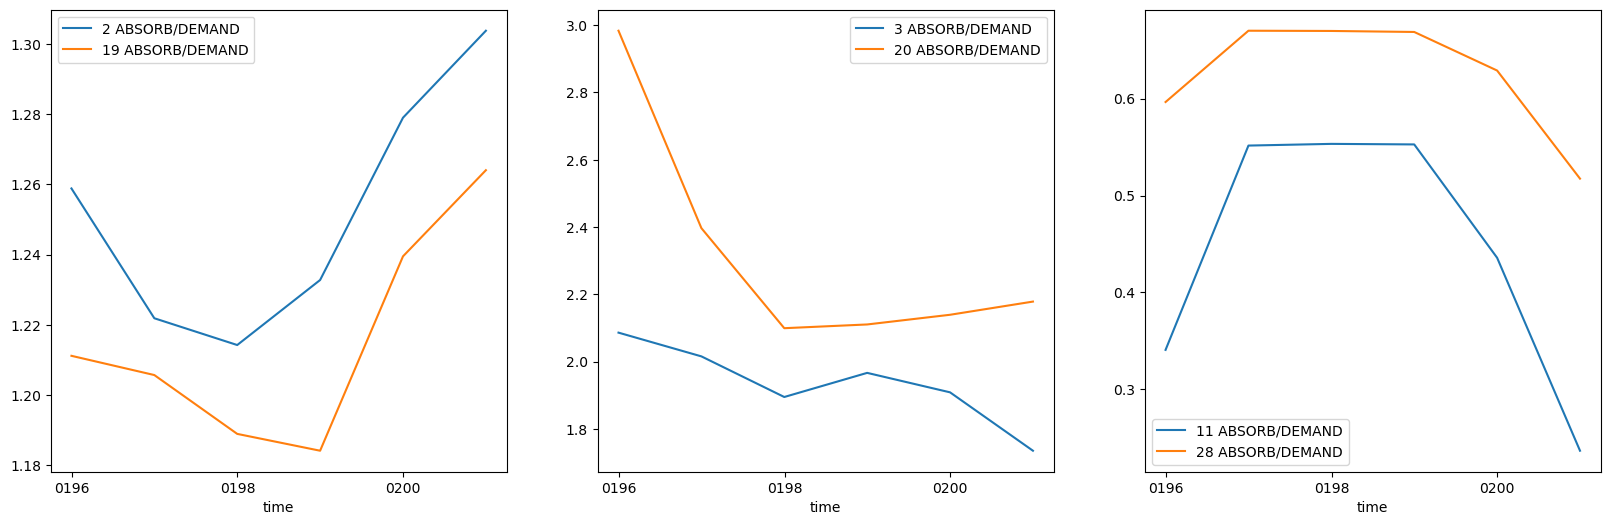

In [31]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    n_absorb = hr2['PLANT_NABSORB'][:, pft].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft) + ' ABSORB/DEMAND', ax = ax)

    n_absorb = hr2['PLANT_NABSORB'][:, pft+17].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft+17].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft+17) + ' ABSORB/DEMAND', ax = ax)

    ax.legend()

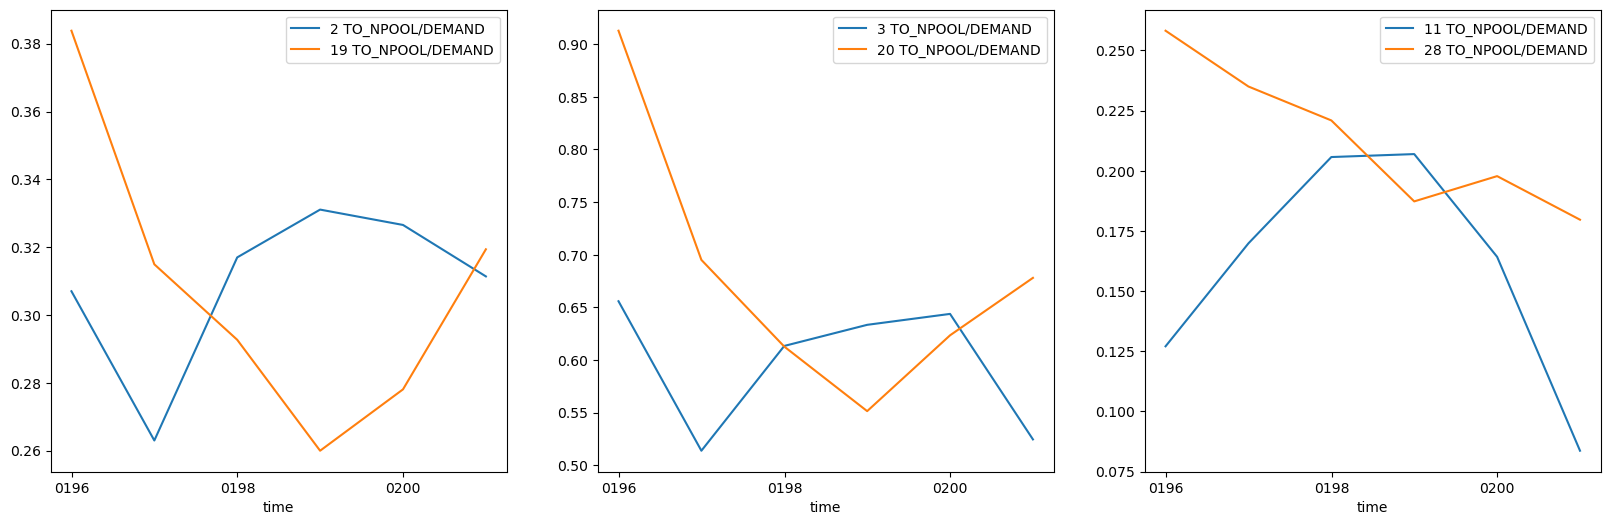

In [34]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    n_absorb = hr2['SMINN_TO_NPOOL'][:, pft].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft) + ' TO_NPOOL/DEMAND', ax = ax)

    n_absorb = hr2['SMINN_TO_NPOOL'][:, pft+17].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft+17].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft+17) + ' TO_NPOOL/DEMAND', ax = ax)

    ax.legend()

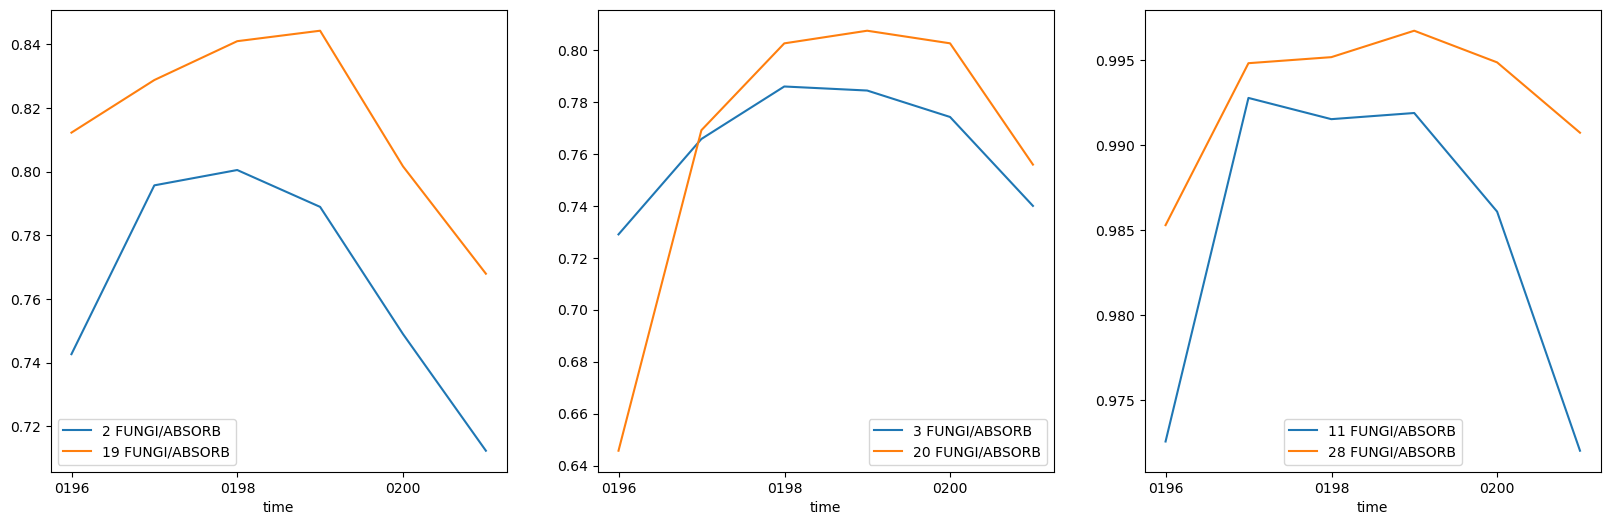

In [35]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    n_absorb = hr2['PLANT_NFUNGI_PATCH'][:, pft].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NABSORB'][:, pft].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft) + ' FUNGI/ABSORB', ax = ax)

    n_absorb = hr2['PLANT_NFUNGI_PATCH'][:, pft+17].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NABSORB'][:, pft+17].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft+17) + ' FUNGI/ABSORB', ax = ax)

    ax.legend()

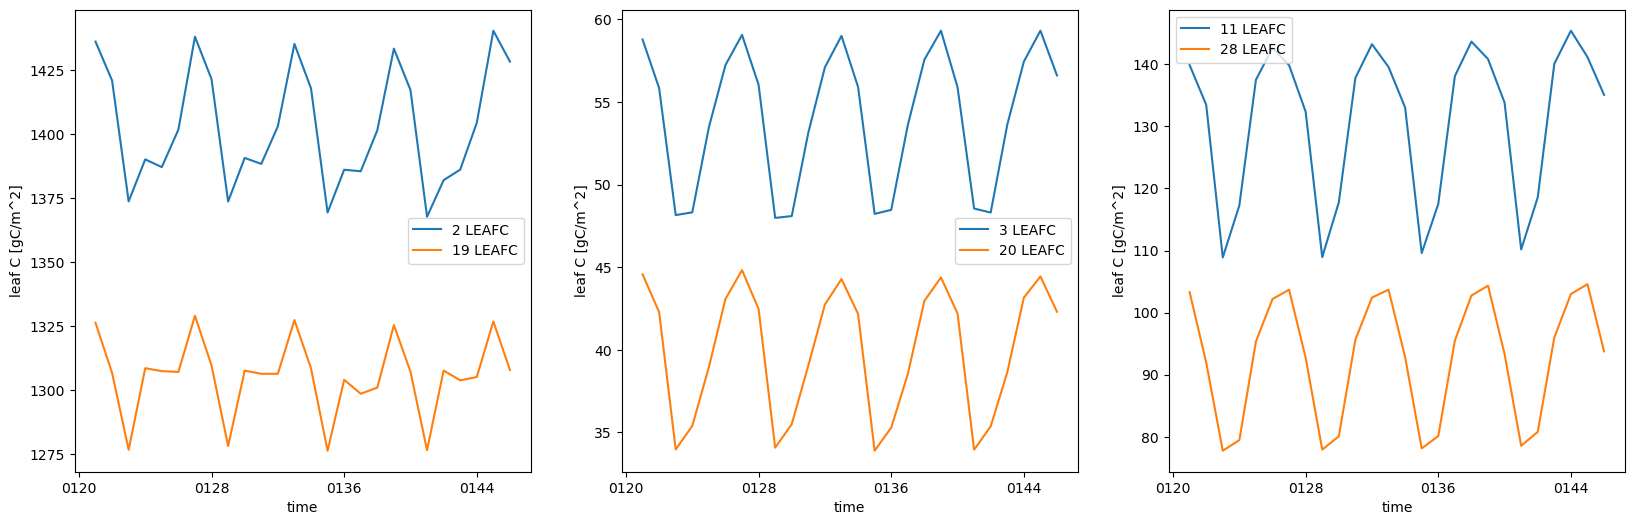

In [16]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['LEAFC'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' LEAFC', ax = ax)
    tlai = hr2['LEAFC'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' LEAFC', ax = ax)
    ax.legend()

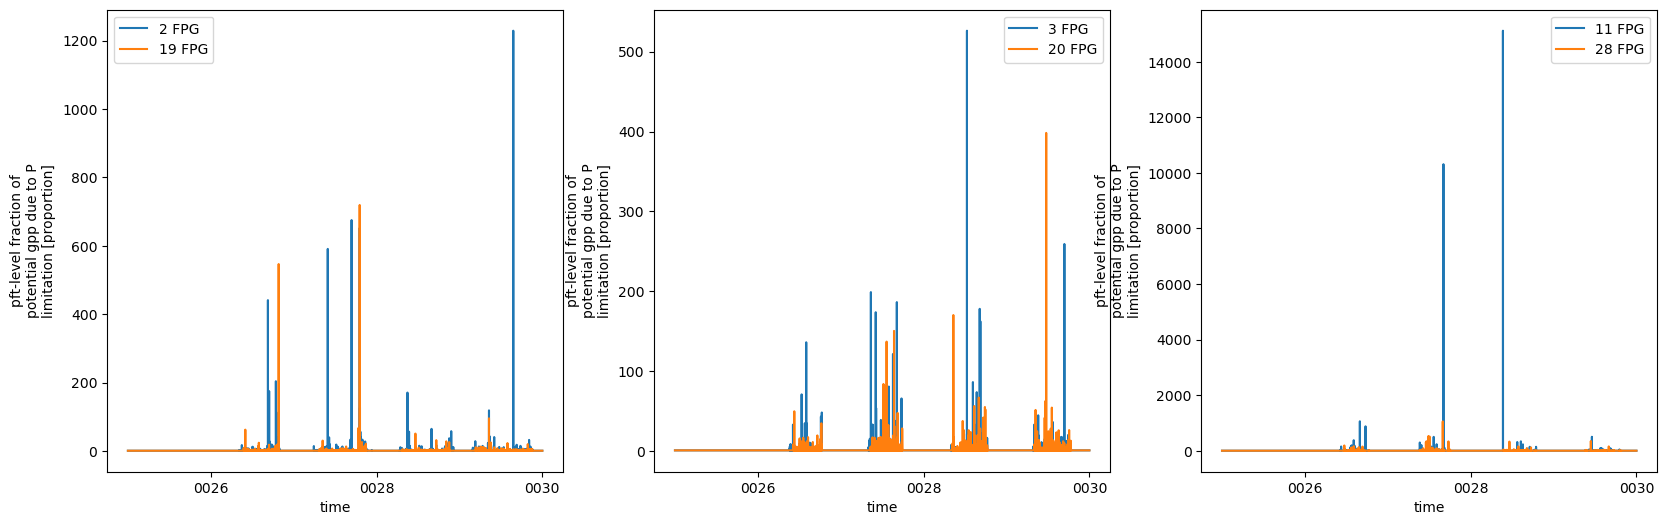

In [6]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['FPG_P_PATCH'][:, pft].plot(label = str(pft) + ' FPG', ax = ax) # resample(time='1Y').mean().
    tlai = hr2['FPG_P_PATCH'][:, pft+17].plot(label = str(pft+17) + ' FPG', ax = ax) # resample(time='1Y').mean().
    ax.legend()

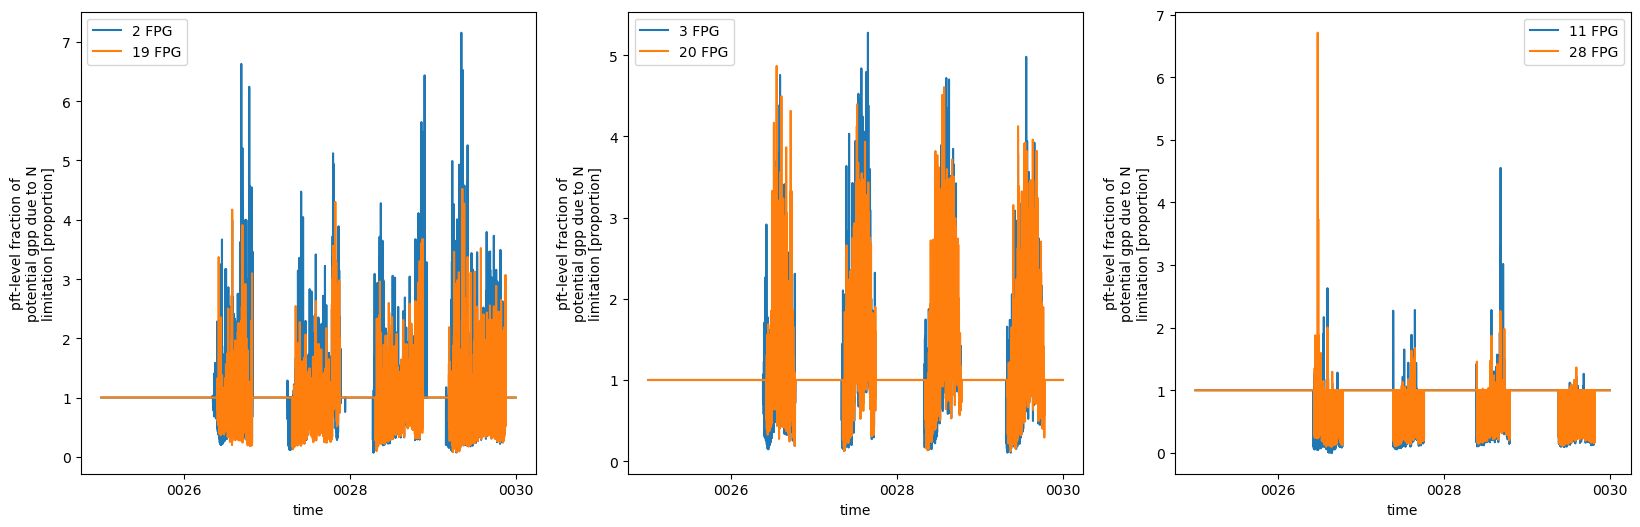

In [28]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    temp = np.minimum(hr2['FPG_PATCH'][:, pft], hr2['FPG_P_PATCH'][:, pft])
    tlai = temp.plot(label = str(pft) + ' FPG', ax = ax) # resample(time='1Y').mean().

    temp = np.minimum(hr2['FPG_PATCH'][:, pft+17], hr2['FPG_P_PATCH'][:, pft+17])
    tlai = temp.plot(label = str(pft+17) + ' FPG', ax = ax) # resample(time='1Y').mean().
    ax.legend()

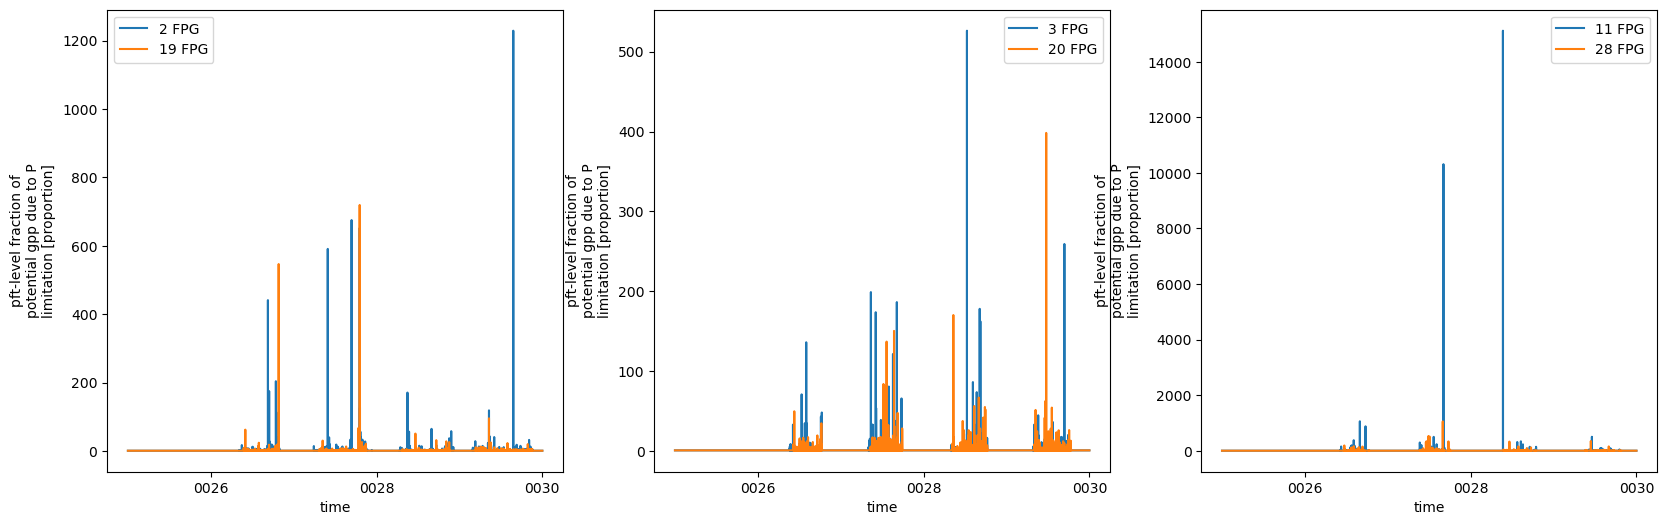

In [29]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    temp = hr2['FPG_P_PATCH'][:, pft]
    tlai = temp.plot(label = str(pft) + ' FPG', ax = ax) # resample(time='1Y').mean().

    temp = hr2['FPG_P_PATCH'][:, pft+17]
    tlai = temp.plot(label = str(pft+17) + ' FPG', ax = ax) # resample(time='1Y').mean().
    ax.legend()

In [27]:
hr2['FPG_PATCH'][12373:12376, 2].values, hr2['FPG_P_PATCH'][12373:12376, 2].values

(array([1.000000e+00, 3.235199e+03, 9.105310e-01], dtype=float32),
 array([1.       , 1.       , 1.1620451], dtype=float32))

In [26]:
hr2['PLANT_NABSORB'][12373:12376, 2].values, hr2['PLANT_NDEMAND'][12373:12376, 2].values, hr2['PLANT_NFUNGI_PATCH'][12373:12376, 2].values

(array([1.9073201e-07, 1.9108266e-07, 1.2515360e-06], dtype=float32),
 array([0.0000000e+00, 5.0233498e-11, 1.1231938e-06], dtype=float32),
 array([0.0000000e+00, 4.7427964e-11, 1.0602565e-06], dtype=float32))

In [16]:
hr2['PLANT_NDEMAND'][12373, 2].values == 0.

True

In [20]:
hr2['SMINN_TO_NPOOL'][12373:12376, 2].values

array([0.0000000e+00, 5.0233498e-11, 1.0227028e-06], dtype=float32)

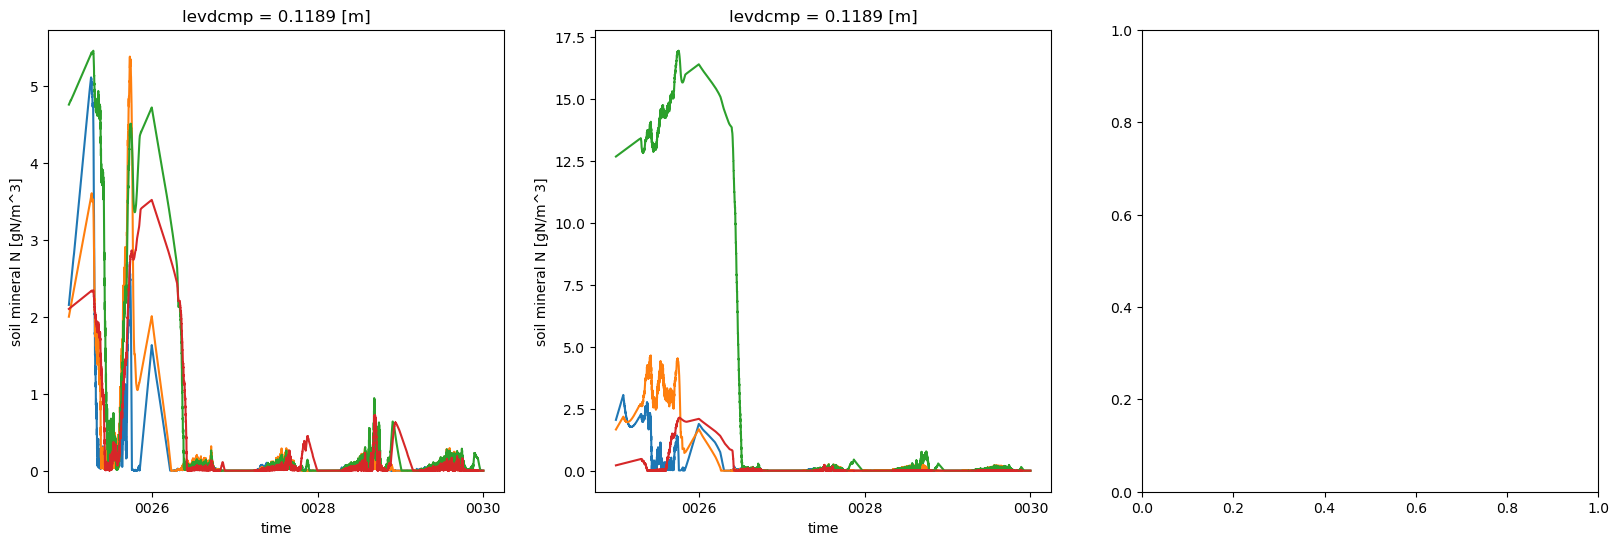

In [22]:
flist = get_colfiles_adsp('20240311_1', range(25,30))
hr = xr.open_mfdataset(flist)

fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,col in enumerate([0,1]):
    ax = axes.flat[i]
    for j in range(4):
        tlai = hr['SMINN_vr'][:, j, col].plot(ax = ax) # resample(time='1Y').mean().
    #ax.legend()

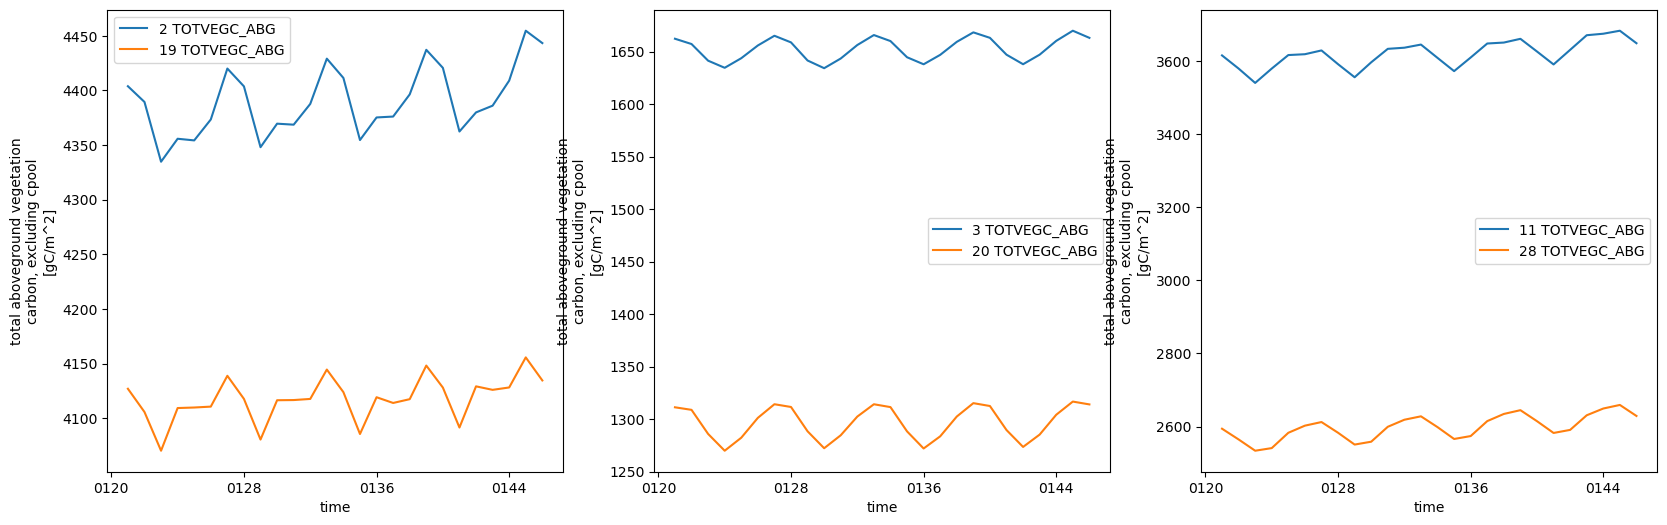

In [14]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['TOTVEGC_ABG'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' TOTVEGC_ABG', ax = ax)
    tlai = hr2['TOTVEGC_ABG'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' TOTVEGC_ABG', ax = ax)
    ax.legend()

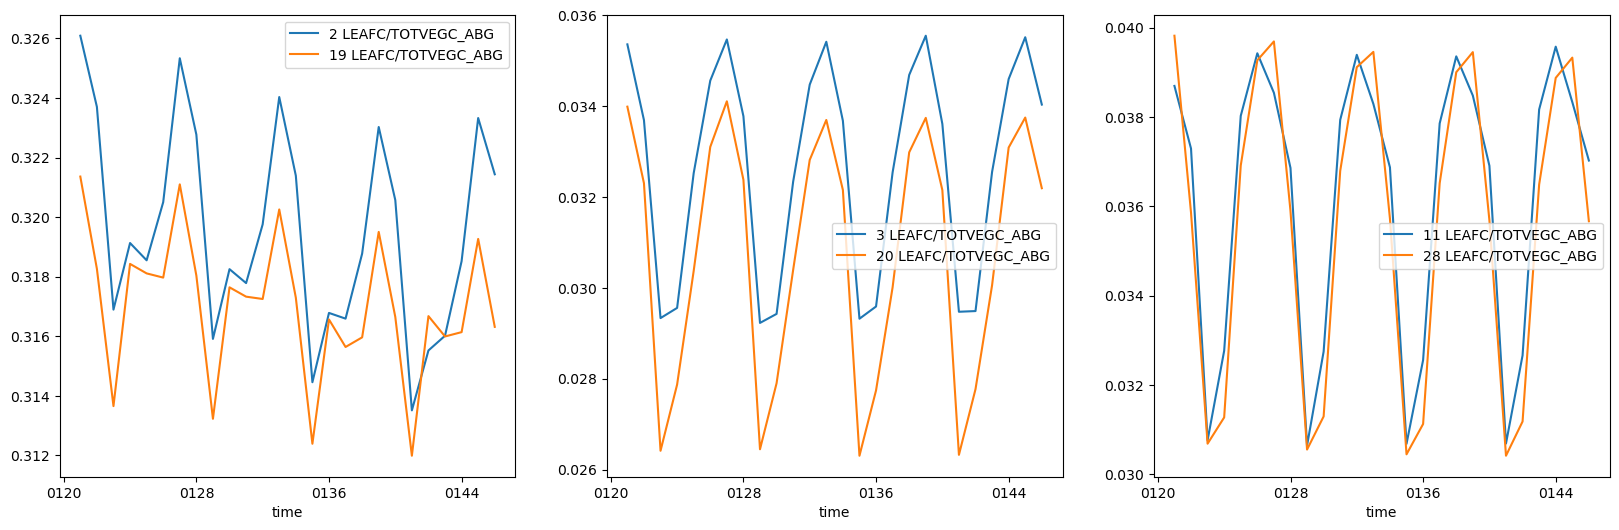

In [13]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['LEAFC'][:, pft].resample(time='1Y').mean()
    totvegc_abg = hr2['TOTVEGC_ABG'][:, pft].resample(time='1Y').mean()
    (tlai / totvegc_abg).plot(label = str(pft) + ' LEAFC/TOTVEGC_ABG', ax = ax)

    tlai = hr2['LEAFC'][:, pft+17].resample(time='1Y').mean()
    totvegc_abg = hr2['TOTVEGC_ABG'][:, pft+17].resample(time='1Y').mean()
    (tlai / totvegc_abg).plot(label = str(pft+17) + ' LEAFC/TOTVEGC_ABG', ax = ax)

    ax.legend()

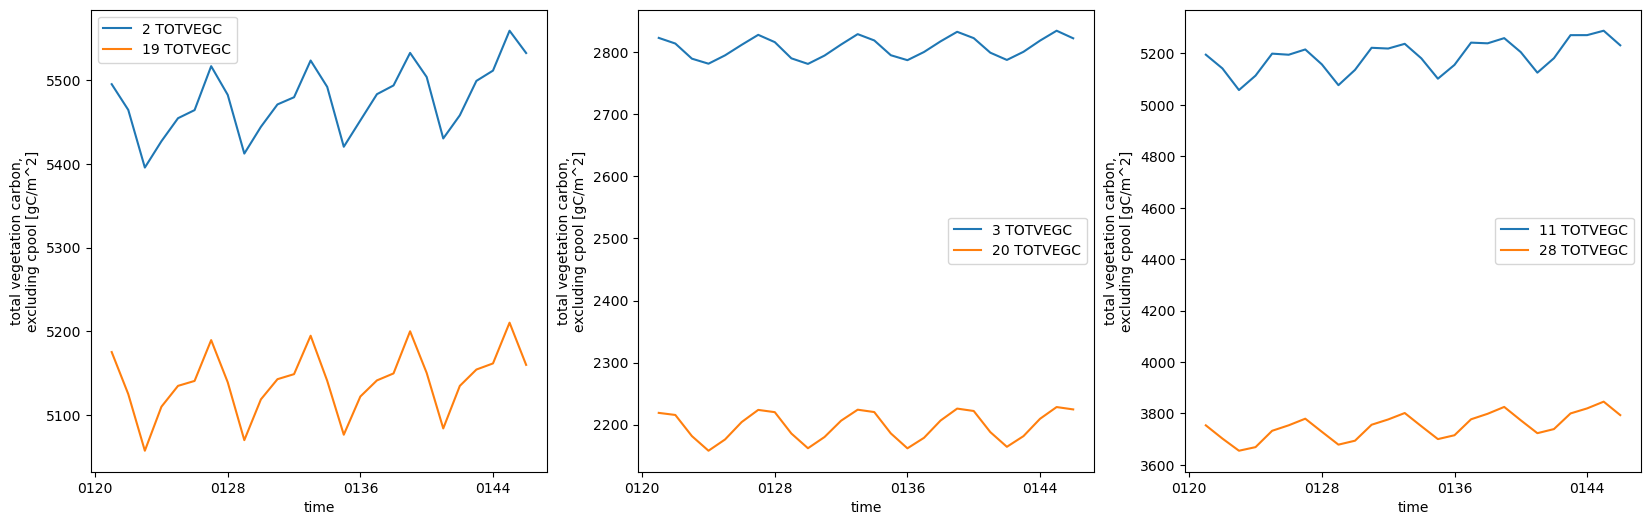

In [12]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['TOTVEGC'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' TOTVEGC', ax = ax)
    tlai = hr2['TOTVEGC'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' TOTVEGC', ax = ax)
    ax.legend()

In [11]:
flist = get_pftfiles_fnsp('20240311_1', range(120,146))
hr2 = xr.open_mfdataset(flist)

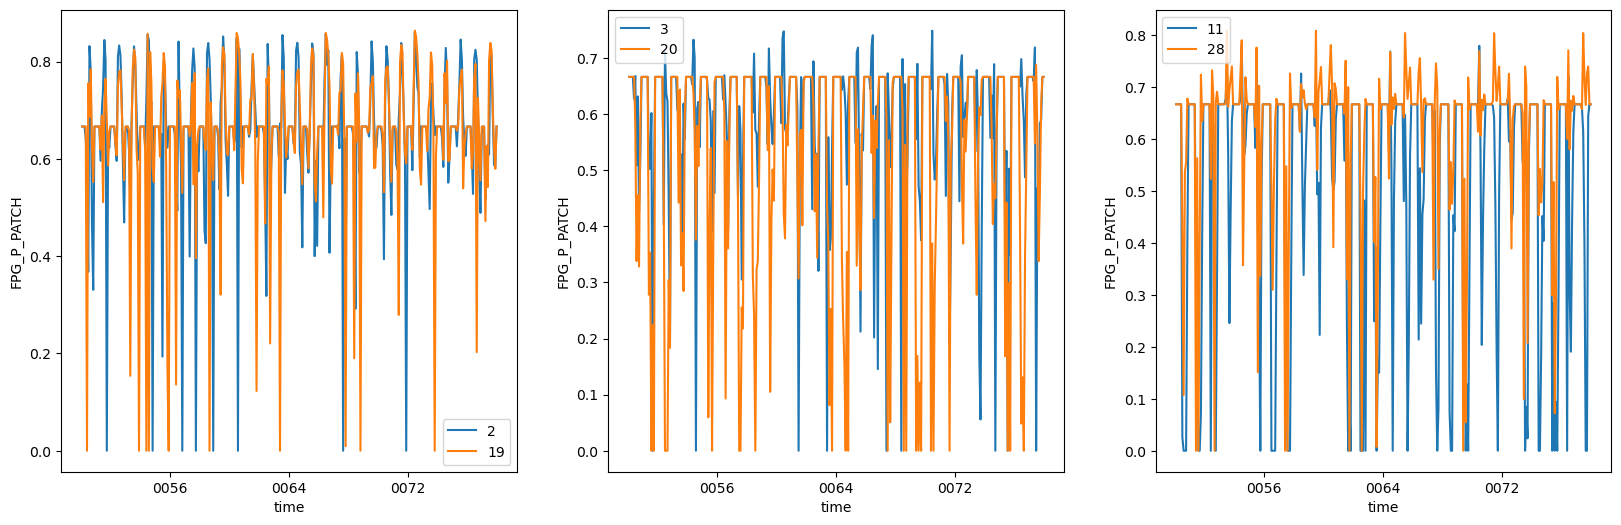

In [3]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    frac_fungi = hr2['FPG_P_PATCH'][:, pft].resample(time='1M').mean()
    frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft, ax = ax)

    frac_fungi = hr2['FPG_P_PATCH'][:, pft + 17].resample(time='1M').mean()
    frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft + 17, ax = ax)

    ax.legend()
    ax.set_ylabel('FPG_P_PATCH')

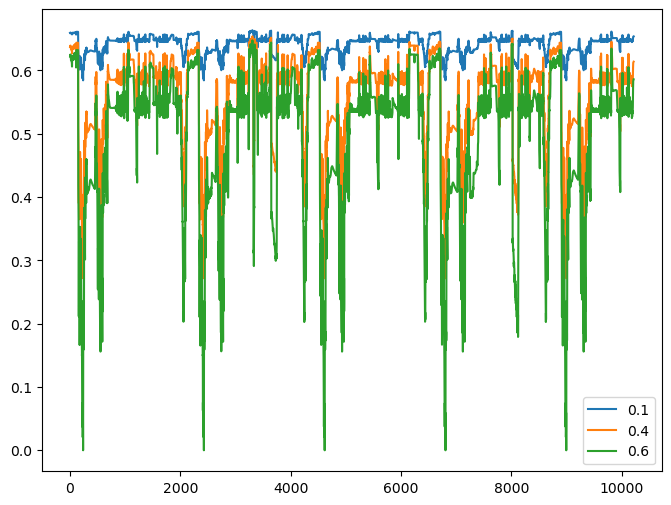

In [4]:
zwt = hr2['ZWT'][:, 0]

plt.figure(figsize = (8, 6))
# zwt = np.linspace(-0.2, 0.4) # more positive -> deeper belowground
for slope in [0.1, 0.4, 0.6]:
    plt.plot(np.maximum(1-(np.exp(zwt/0.3 * slope) - 0.5)/1.5,0), label = slope)
    # plt.hist(np.maximum(1-(np.exp(zwt/0.3 * slope) - 0.5)/1.5,0))
plt.legend()